In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fixing the random seed makes our split reproducible: everyone who runs
# this notebook gets the same train / val / test rows.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
df = pd.read_csv('heart_disease_cleaned.csv')

print(f"Shape:         {df.shape}")
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

df.head()


Shape:         (29891, 19)
Duplicates:    0
Missing (NaN): 0


,Age,Gender,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,35,0,33.0,2,0,1,1,1,1,0,1,1,0,111,72,60,145,206,0
1,75,1,37.4,2,1,0,1,0,0,0,1,0,0,171,92,109,105,290,1
2,67,1,22.3,2,1,0,0,0,1,0,0,0,0,153,82,85,145,156,1
3,74,1,35.7,1,0,0,0,0,0,0,0,0,0,114,69,87,117,195,0
4,38,1,34.7,1,2,2,1,0,0,0,0,1,0,106,102,67,116,284,0


No Heart Disease: 16024  (53.6%)
Heart Disease:    13867  (46.4%)


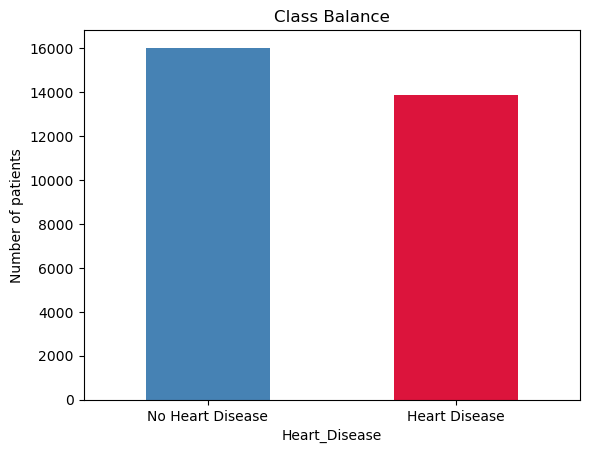

In [4]:
counts = df['Heart_Disease'].value_counts()

print(f"No Heart Disease: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"Heart Disease:    {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()

In [5]:
df

,Age,Gender,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,35,0,33.0,2,0,1,1,1,1,0,1,1,0,111,72,60,145,206,0
1,75,1,37.4,2,1,0,1,0,0,0,1,0,0,171,92,109,105,290,1
2,67,1,22.3,2,1,0,0,0,1,0,0,0,0,153,82,85,145,156,1
3,74,1,35.7,1,0,0,0,0,0,0,0,0,0,114,69,87,117,195,0
4,38,1,34.7,1,2,2,1,0,0,0,0,1,0,106,102,67,116,284,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29886,39,0,18.1,2,2,0,1,2,0,0,0,0,0,111,105,80,141,160,0
29887,53,1,35.8,2,0,0,2,0,0,0,1,0,0,141,96,70,148,252,0
29888,38,0,32.3,0,0,0,0,0,0,0,0,0,0,178,94,90,75,235,0
29889,68,1,18.6,2,2,0,1,2,0,0,0,0,0,118,110,106,113,177,0


In [6]:
Features = ['Age', 'Gender', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease']
Features

['Age',
 'Gender',
 'BMI',
 'Smoking',
 'Alcohol_Intake',
 'Physical_Activity',
 'Diet',
 'Stress_Level',
 'Hypertension',
 'Diabetes',
 'Hyperlipidemia',
 'Family_History',
 'Previous_Heart_Attack',
 'Systolic_BP',
 'Diastolic_BP',
 'Heart_Rate',
 'Blood_Sugar_Fasting',
 'Cholesterol_Total',
 'Heart_Disease']

In [7]:
X = df[Features].astype(np.float32)
y = df["Heart_Disease"].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train: {len(X_train):>4} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {len(X_val):>4} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {len(X_test):>4} rows  ({y_test.mean():.1%} positive)")
# print(df["Age"])



Train: 20935 rows  (46.4% positive)
Val:   4472 rows  (46.4% positive)
Test:  4484 rows  (46.4% positive)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Example, first row before and after:")
print("Before:", X_train.iloc[0, :5].)
print("After: ", X_train_scaled[0, :5].round(2))


Scaling done. Example, first row before and after:
Before: <bound method IndexOpsMixin.to_numpy of Age               35.0
Gender             1.0
BMI               34.5
Smoking            0.0
Alcohol_Intake     0.0
Name: 6987, dtype: float32>
After:  [-1.35  1.    0.87 -1.76 -0.9 ]


In [12]:
import json

# --- CSV: scaled features + target, one file per split ---
train_df = pd.DataFrame(X_train_scaled, columns=Features)
train_df['Heart_Disease'] = y_train

val_df = pd.DataFrame(X_val_scaled, columns=Features)
val_df['Heart_Disease'] = y_val

test_df = pd.DataFrame(X_test_scaled, columns=Features)
test_df['Heart_Disease'] = y_test

train_df.to_csv('heart_disease_train.csv', index=False)
val_df.to_csv('heart_disease_val.csv', index=False)
test_df.to_csv('heart_disease_test.csv', index=False)

print("Saved heart_disease_train.csv", train_df.shape)
print("Saved heart_disease_val.csv  ", val_df.shape)
print("Saved heart-disease_test.csv ", test_df.shape)

Saved heart_disease_train.csv (20935, 19)
Saved heart_disease_val.csv   (4472, 19)
Saved heart-disease_test.csv  (4484, 19)


In [21]:
metadata = {
    'features': Features,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}

with open('heart_disease_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved heart_disease_metadata.json")

Saved heart_disease_metadata.json


In [24]:
prepared_data = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'scaler': scaler,
    'features': Features,
}

with open('heart_disease_prepared.pkl', 'wb') as f:
    pickle.dump(prepared_data, f)

print("Saved heart_disease_prepared.pkl")

Saved heart_disease_prepared.pkl
